In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [36]:
foldername = 'results/20250224/'
pickels = glob.glob(f'{foldername}*pkl')

df_list = []

for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [37]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",25572,"[496, 104, 180, 184]",0.999321,"[[647.6666666666666, 125.2222222222222]]",0.983013,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",739,25573.0,...,90.220953,"(647.6666666666666, 125.2222222222222)",195.880065,172.851822,122.425041,112.776192,216.064777,A2-01,A2h pH 6.2,1.25
1,"[[False, False, False, False, False, False, Fa...",25715,"[710, 349, 199, 178]",1.004832,"[[856.1944444444445, 370.5833333333333]]",0.986448,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",763,25714.0,...,90.472862,"(856.1944444444445, 370.5833333333333)",199.361481,171.762054,124.600925,113.091077,214.702568,A2-01,A2h pH 6.2,1.25
2,"[[False, False, False, False, False, False, Fa...",9187,"[242, 725, 129, 96]",0.989888,"[[245.66666666666669, 763.5277777777778]]",0.986046,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",455,9187.0,...,54.076917,"(245.66666666666669, 763.5277777777778)",129.757466,92.556625,81.098416,67.596146,115.695782,A2-01,A2h pH 6.2,1.25
3,"[[False, False, False, False, False, False, Fa...",26167,"[556, 452, 192, 181]",0.994633,"[[677.75, 549.1944444444445]]",0.981897,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",771,26167.0,...,91.264532,"(677.75, 549.1944444444445)",204.474937,175.425049,127.796836,114.080665,219.281311,A2-01,A2h pH 6.2,1.25
4,"[[False, False, False, False, False, False, Fa...",22845,"[0, 502, 189, 185]",0.885857,"[[111.66666666666667, 620.6388888888889]]",0.891200,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",787,22851.0,...,85.274787,"(111.66666666666667, 620.6388888888889)",208.124962,182.950516,130.078102,106.593484,228.688145,A2-01,A2h pH 6.2,1.25


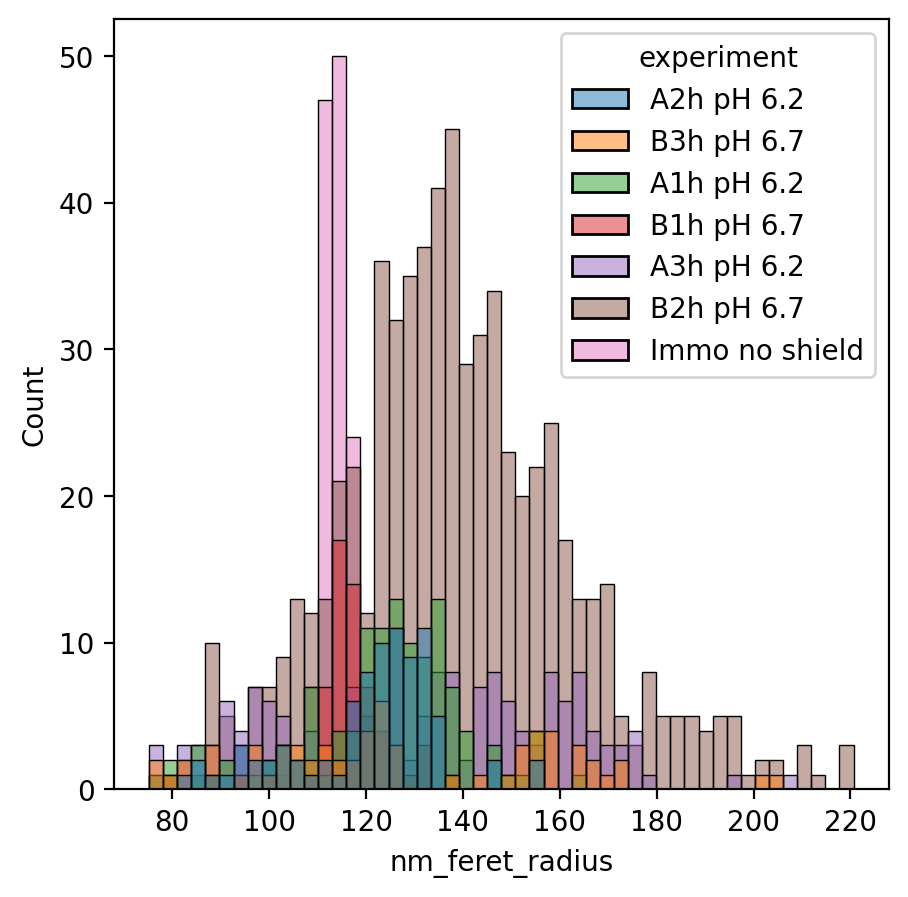

In [49]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [39]:
exclusion_list = ['A2-02', 'A3-01', 'A3-02', 'B2-02', 'B2-03', 'B2-04', 'B2-05', 'B3-01']

In [40]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]

In [41]:
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 90, 130, x['nm_per_pixel'], True), axis=1)

/var/folders/hx/cphylf_x45bdc9bx9rm660lh0000gn/T/ipykernel_21036/1292724228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 90, 130, x['nm_per_pixel'], True), axis=1)


In [43]:
q5, q95 = df_filtered.hough_radius.quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered['hough_radius'] < q95) & (df_filtered['hough_radius'] > q5)]

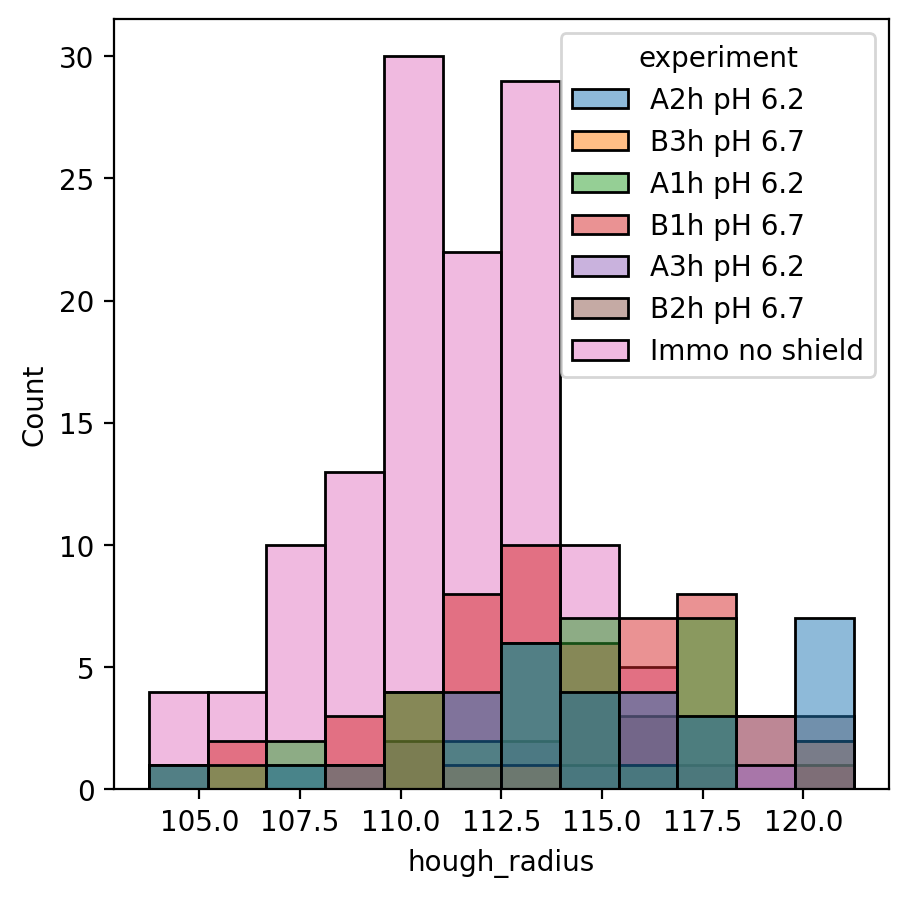

In [50]:
plt.figure(figsize=(5,5), dpi=200)
plot_df = df_filtered.dropna()
sns.histplot(data=plot_df, x='hough_radius', hue='experiment')
plt.savefig(f'{foldername}/filtered_particle_measurements')

<Figure size 1000x1000 with 0 Axes>

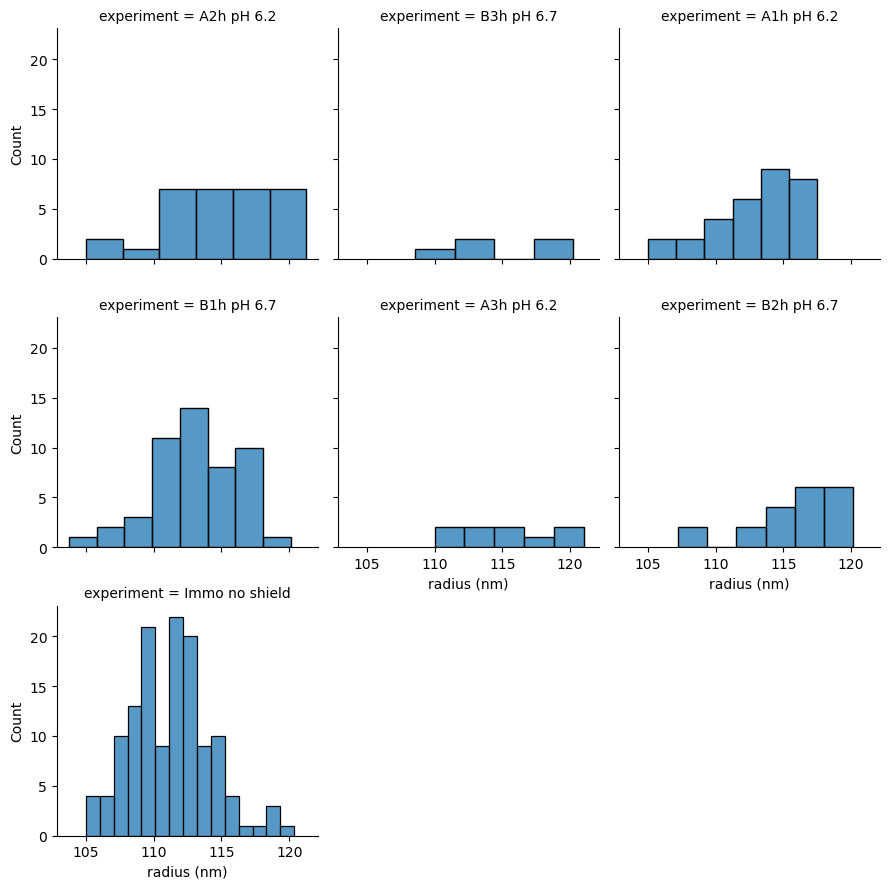

In [53]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, 'hough_radius')
g.set_axis_labels("radius (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [46]:
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values='hough_radius')
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,A1h pH 6.2,A2h pH 6.2,A3h pH 6.2,B1h pH 6.7,B2h pH 6.7,B3h pH 6.7,Immo no shield
0,111.89,121.25,110.0,116.25,115.83,120.0,112.1
1,110.22,117.5,112.5,108.68,118.69,113.56,109.74
2,113.56,115.0,115.0,115.83,118.69,120.24,114.46
3,111.89,108.75,118.75,105.82,115.83,111.89,110.92
4,113.56,115.0,112.5,114.4,120.12,108.55,116.82


In [47]:
analysis_df = analyze_samples(experiment_df, 'Immo no shield', alpha=0.04)
analysis_df.to_csv(f'{foldername}/analysis.csv')
analysis_df

,A1h pH 6.2,A2h pH 6.2,A3h pH 6.2,B1h pH 6.7,B2h pH 6.7,B3h pH 6.7
thickness,1.981708,3.740095,3.929773,1.846773,4.472273,3.567773
CI_lower,0.507365,2.06481,0.453251,0.707534,2.671483,-3.295377
CI_upper,3.456052,5.415381,7.406294,2.986011,6.273062,10.430923
p_value,0.006815,0.00003,0.024131,0.001112,0.000017,0.196119
significance,Significant,Significant,Significant,Significant,Significant,Not significant
significance_level,98.0,98.0,98.0,98.0,98.0,98.0
SEM,0.69453,0.787358,1.43653,0.545513,0.827718,2.313155
DOF,40.065462,37.475287,8.538241,78.623594,23.241099,4.100779
N_sample,31,31,9,50,20,5
N_ref,132,132,132,132,132,132


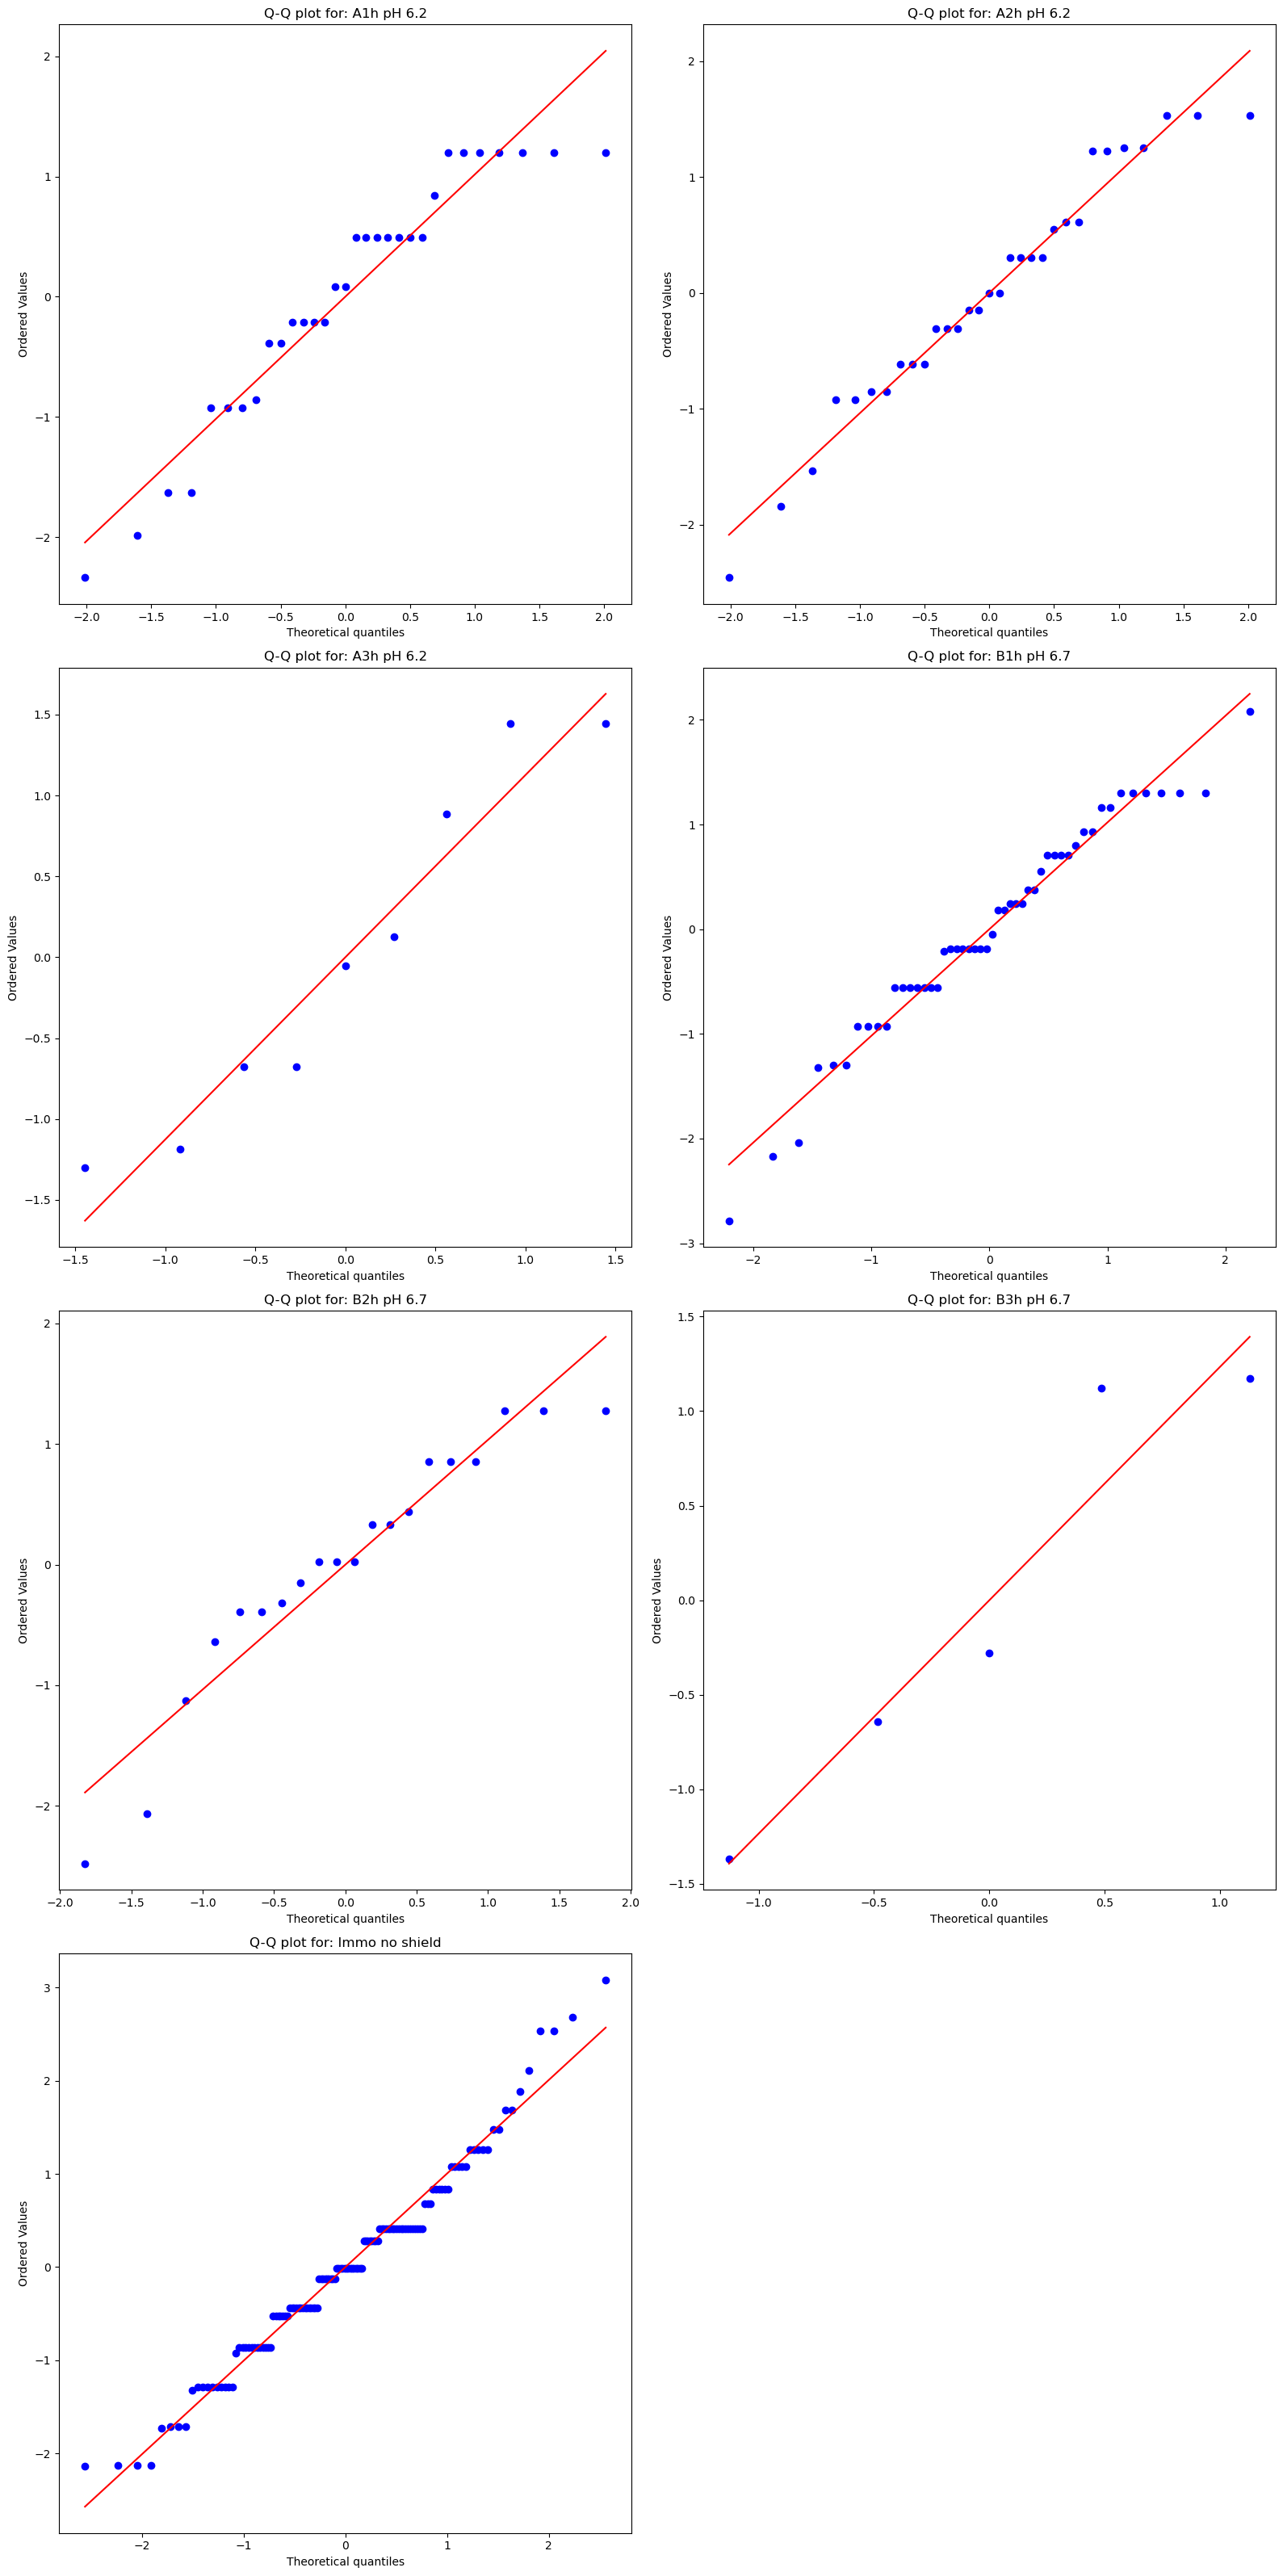

<Figure size 640x480 with 0 Axes>

In [52]:
plot_quantiles(experiment_df, foldername)
